# Background-relative beta-effect analysis

This notebook tests whether EAC anticyclonic eddies (AEs) have a northward/equatorward residual drift and cyclonic eddies (CEs) a southward/poleward residual drift after subtracting the strong southwestward background flow. It uses the cache produced by `build_background_cache.py`.

The primary sample has planetary PV-gradient magnitude greater than topographic PV-gradient magnitude. The topographic term uses $(w+f)\nabla h/h^2$, so the dominance mask is calculated separately for AEs and CEs.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path.cwd()
if not (HERE / 'background_flow_tools.py').exists():
    HERE = Path('MRes/seacofs_eddy_tilt_analysis/beta_effect_background_flow').resolve()
sys.path.insert(0, str(HERE))
sys.path.insert(0, str(HERE.parent))

import seacofs_tilt_tools as tilt
from background_flow_tools import BackgroundConfig, load_background_cache
from analysis_tools import (METHODS, add_track_velocity, add_residual_velocities,
                            propagation_summary, eddy_bootstrap_ci,
                            vorticity_budget_summary)
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Load eddies and polarity-specific PV-gradient terms

`topo_plan_ratio = log(|topographic PV gradient| / |planetary PV gradient|)`. Therefore values below zero identify planetary-dominant observations. Because the topographic numerator contains `w + f`, AE and CE masks need not select the same locations.

In [2]:
paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df, _ = tilt.load_tilt_tables(paths)
df = tilt.add_pv_gradient_terms(df, grid)
primary = df.loc[df['topo_plan_ratio'] < 0].copy()
pd.crosstab(primary['Cyc'], columns='observations').join(
    primary.groupby('Cyc')['Eddy'].nunique().rename('eddies'))

,observations,eddies
Cyc,,
AE,13544,903
CE,3239,706


## 2. Load the one-pass background cache

Run `python build_background_cache.py --workers 4` in this folder first. Four estimates are retained: instantaneous annulus surface flow (primary), instantaneous thickness-weighted 0–500 m annulus flow, monthly surface climatology, and monthly thickness-weighted 0–500 m climatology.

In [3]:
config = BackgroundConfig()
background = load_background_cache(config)
primary = primary.merge(background, on=['Eddy', 'Day'], how='inner', validate='one_to_one')
primary = add_track_velocity(primary, grid.angle, window=5)
primary = add_residual_velocities(primary)
print(f"Matched {len(primary):,} observations from {primary['Eddy'].nunique():,} eddies")

/home/z5297792/UNSW-MRes/MRes/seacofs_eddy_tilt_analysis/beta_effect_background_flow/analysis_tools.py:36: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out["dxc_km_day"] = out.groupby("Eddy", group_keys=False).apply(


Matched 16,783 observations from 1,609 eddies


/home/z5297792/UNSW-MRes/MRes/seacofs_eddy_tilt_analysis/beta_effect_background_flow/analysis_tools.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out["dyc_km_day"] = out.groupby("Eddy", group_keys=False).apply(


In [16]:
def xy_to_distance_direction(x, y):
    """
    Convert x/y components to distance and direction.

    Assumes:
        x = eastward component
        y = northward component

    Returns:
        distance  : sqrt(x^2 + y^2)
        direction : degrees clockwise from North
                    (0=N, 90=E, 180=S, 270=W)
    """
    distance = np.hypot(x, y)
    direction = (np.degrees(np.arctan2(x, y)) + 360) % 360

    return distance, direction

KM_DAY_TO_M_S = 1000.0 / 86400.0

distance, direction = xy_to_distance_direction(primary.track_east_ms, primary.track_north_ms)
primary['track_dis'] = distance / KM_DAY_TO_M_S
primary['track_dir'] = direction

distance, direction = xy_to_distance_direction(primary.clim_surface_east_ms, primary.clim_surface_north_ms)
primary['clim_surface_dis'] = distance / KM_DAY_TO_M_S
primary['clim_surface_dir'] = direction

distance, direction = xy_to_distance_direction(primary.ann_surface_east_ms, primary.ann_surface_north_ms)
primary['ann_surface_dis'] = distance / KM_DAY_TO_M_S
primary['ann_surface_dir'] = direction

distance, direction = xy_to_distance_direction(primary.ann_500_east_ms, primary.ann_500_north_ms)
primary['ann_500_dis'] = distance / KM_DAY_TO_M_S
primary['ann_500_dir'] = direction

distance, direction = xy_to_distance_direction(primary.ann_surface_residual_east_ms, primary.ann_surface_residual_north_ms)
primary['ann_surface_residual_dis'] = distance / KM_DAY_TO_M_S
primary['ann_surface_residual_dir'] = direction


In [5]:
primary.columns

Index(['Eddy', 'Day', 'Cyc', 'lon', 'lat', 'ic_x', 'jc_x', 'xc', 'yc', 'w',
       'Omega', 'q11', 'q12', 'q22', 'Rc', 'psi0', 'AR', 'R', 'Age', 'Date',
       'fname', 'TiltDis', 'TiltDir', 'f', 'h', 'dhdx', 'dhdy', 'beta',
       'PV_grad_plan_x', 'PV_grad_plan_y', 'PV_grad_topo_x', 'PV_grad_topo_y',
       'PV_grad_x', 'PV_grad_y', 'PV_grad_plan_mag', 'PV_grad_plan_theta',
       'PV_grad_topo_mag', 'PV_grad_topo_theta', 'PV_grad_mag',
       'PV_grad_theta', 'dtheta_PV_grad', 'dtheta_PV_grad_topo',
       'dtheta_PV_grad_plan', 'Ro', 'topo_plan_ratio', 'month', 'ic_y', 'jc_y',
       'ann_surface_east_ms', 'ann_surface_north_ms', 'ann_500_east_ms',
       'ann_500_north_ms', 'clim_surface_east_ms', 'clim_surface_north_ms',
       'clim_500_east_ms', 'clim_500_north_ms', 'dxc_km_day', 'dyc_km_day',
       'track_east_ms', 'track_north_ms', 'expected_sign',
       'ann_surface_residual_east_ms', 'ann_surface_residual_north_ms',
       'ann_surface_aligned_residual_north_ms', 'ann_500

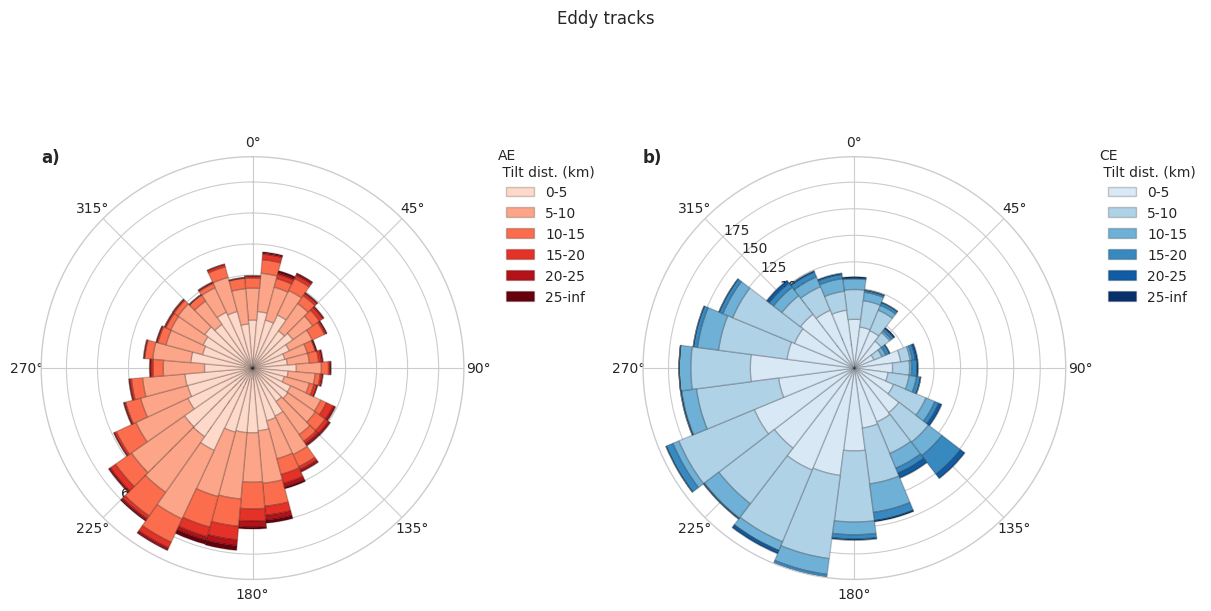

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(12, 7), subplot_kw={"projection": "polar"}, constrained_layout=True)
mag_bins = [0, 5, 10, 15, 20, 25, np.inf]
for ax, cyc, colors in zip(axs, ["AE", "CE"], [plt.cm.Reds(np.linspace(0.15, 1, len(mag_bins) - 1)), plt.cm.Blues(np.linspace(0.15, 1, len(mag_bins) - 1))]):
    subset = primary.loc[primary.Cyc == cyc].dropna(subset=["track_dir", "track_dis"])
    tilt.plot_windrose(ax, subset, title='', colors=colors, mag='track_dis', theta='track_dir', mag_bins=mag_bins)#, rlim=2300)# 
    ax.legend(title=f"{cyc}\n Tilt dist. (km)", loc="upper left", bbox_to_anchor=(1.05, 1.05), frameon=False)

    ax.text(-0.0, 1.02, 'a)' if cyc=='AE' else 'b)', transform=ax.transAxes,
                fontsize=12, fontweight='bold', va='top', ha='left')
plt.suptitle('Eddy tracks')
plt.show()

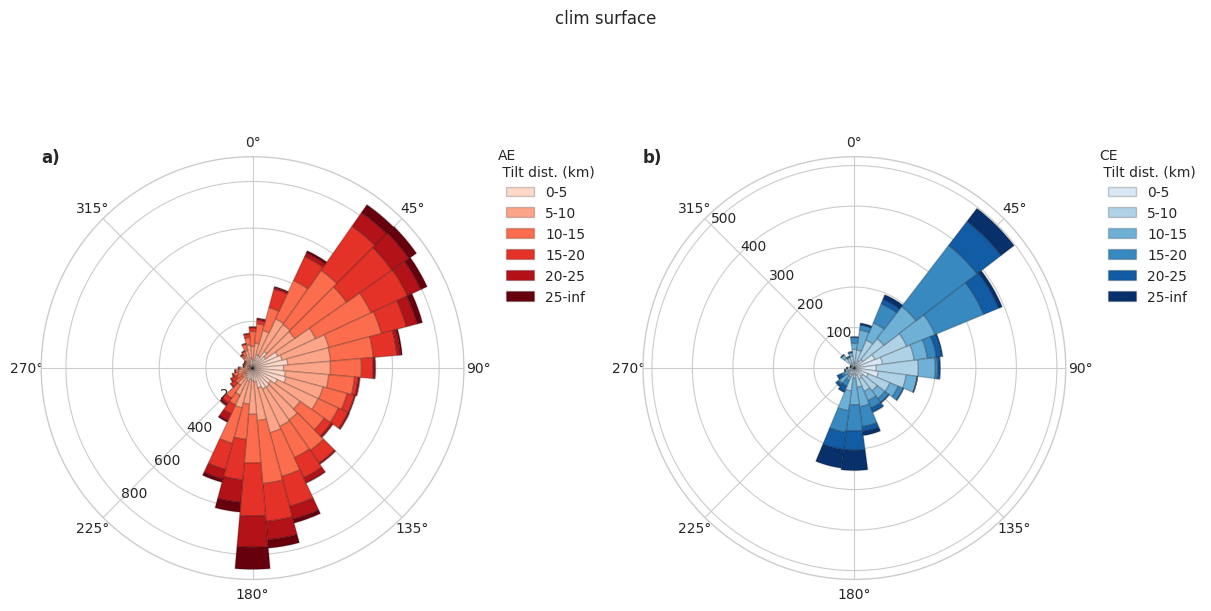

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(12, 7), subplot_kw={"projection": "polar"}, constrained_layout=True)
mag_bins = [0, 5, 10, 15, 20, 25, np.inf]
for ax, cyc, colors in zip(axs, ["AE", "CE"], [plt.cm.Reds(np.linspace(0.15, 1, len(mag_bins) - 1)), plt.cm.Blues(np.linspace(0.15, 1, len(mag_bins) - 1))]):
    subset = primary.loc[primary.Cyc == cyc].dropna(subset=["clim_surface_dir", "clim_surface_dis"])
    tilt.plot_windrose(ax, subset, title='', colors=colors, mag='clim_surface_dis', theta='clim_surface_dir', mag_bins=mag_bins)#, rlim=2300)# 
    ax.legend(title=f"{cyc}\n Tilt dist. (km)", loc="upper left", bbox_to_anchor=(1.05, 1.05), frameon=False)

    ax.text(-0.0, 1.02, 'a)' if cyc=='AE' else 'b)', transform=ax.transAxes,
                fontsize=12, fontweight='bold', va='top', ha='left')
plt.suptitle('clim surface')
plt.show()


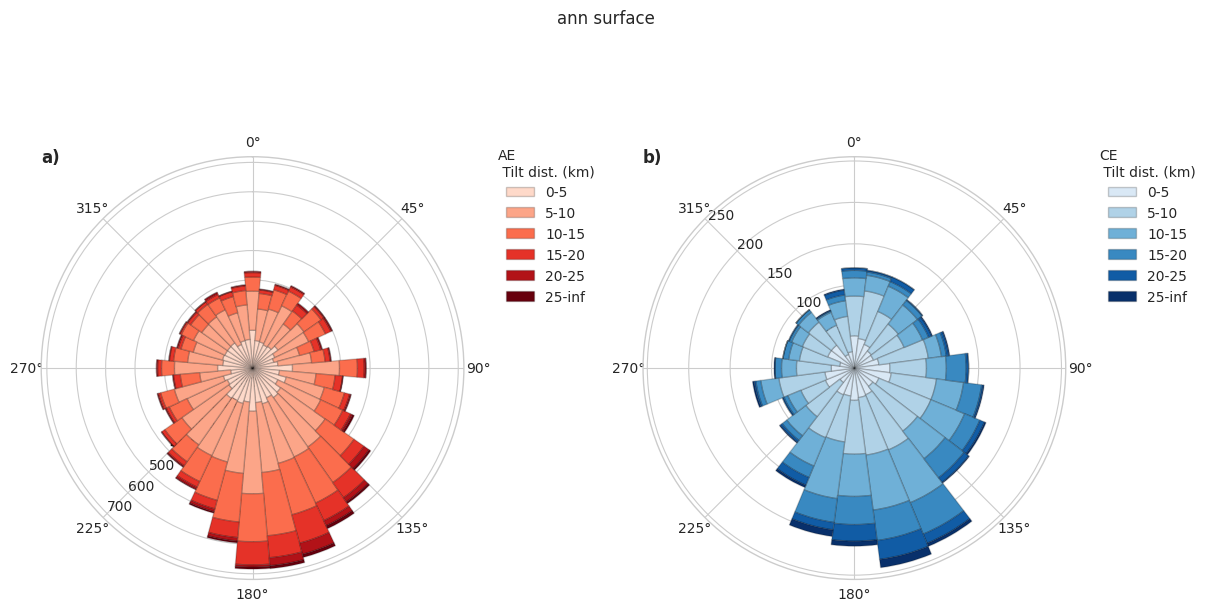

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(12, 7), subplot_kw={"projection": "polar"}, constrained_layout=True)
mag_bins = [0, 5, 10, 15, 20, 25, np.inf]
for ax, cyc, colors in zip(axs, ["AE", "CE"], [plt.cm.Reds(np.linspace(0.15, 1, len(mag_bins) - 1)), plt.cm.Blues(np.linspace(0.15, 1, len(mag_bins) - 1))]):
    subset = primary.loc[primary.Cyc == cyc].dropna(subset=["ann_surface_dir", "ann_surface_dis"])
    tilt.plot_windrose(ax, subset, title='', colors=colors, mag='ann_surface_dis', theta='ann_surface_dir', mag_bins=mag_bins)#, rlim=2300)# 
    ax.legend(title=f"{cyc}\n Tilt dist. (km)", loc="upper left", bbox_to_anchor=(1.05, 1.05), frameon=False)

    ax.text(-0.0, 1.02, 'a)' if cyc=='AE' else 'b)', transform=ax.transAxes,
                fontsize=12, fontweight='bold', va='top', ha='left')
plt.suptitle('ann surface')
plt.show()


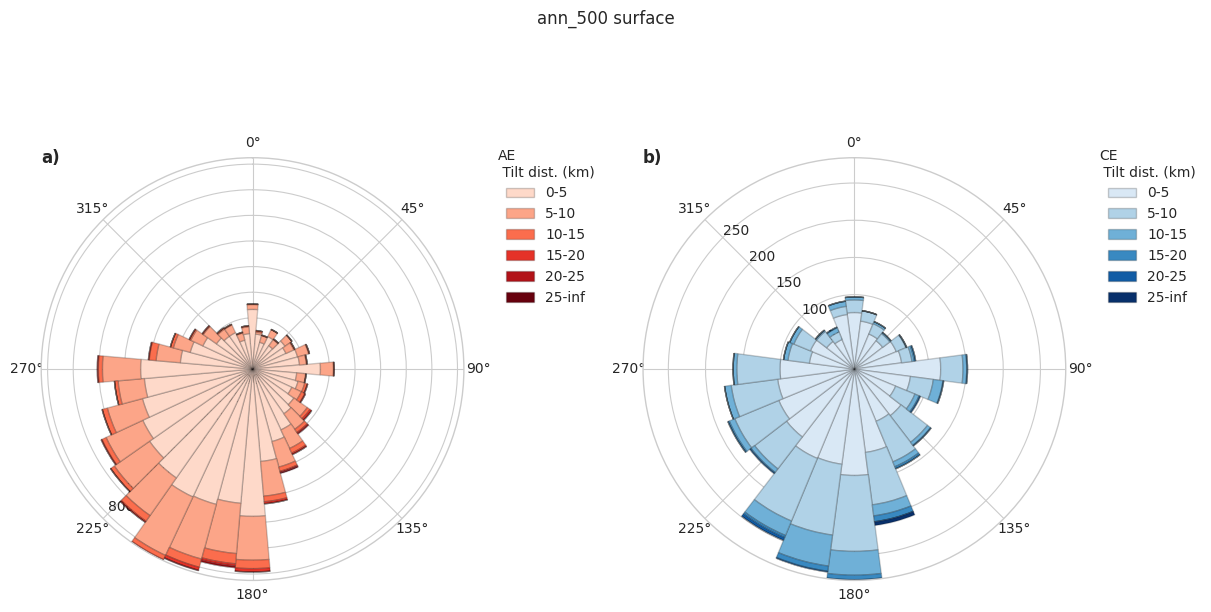

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(12, 7), subplot_kw={"projection": "polar"}, constrained_layout=True)
mag_bins = [0, 5, 10, 15, 20, 25, np.inf]
for ax, cyc, colors in zip(axs, ["AE", "CE"], [plt.cm.Reds(np.linspace(0.15, 1, len(mag_bins) - 1)), plt.cm.Blues(np.linspace(0.15, 1, len(mag_bins) - 1))]):
    subset = primary.loc[primary.Cyc == cyc].dropna(subset=["ann_500_dir", "ann_500_dis"])
    tilt.plot_windrose(ax, subset, title='', colors=colors, mag='ann_500_dis', theta='ann_500_dir', mag_bins=mag_bins)#, rlim=2300)# 
    ax.legend(title=f"{cyc}\n Tilt dist. (km)", loc="upper left", bbox_to_anchor=(1.05, 1.05), frameon=False)

    ax.text(-0.0, 1.02, 'a)' if cyc=='AE' else 'b)', transform=ax.transAxes,
                fontsize=12, fontweight='bold', va='top', ha='left')
plt.suptitle('ann_500 surface')
plt.show()

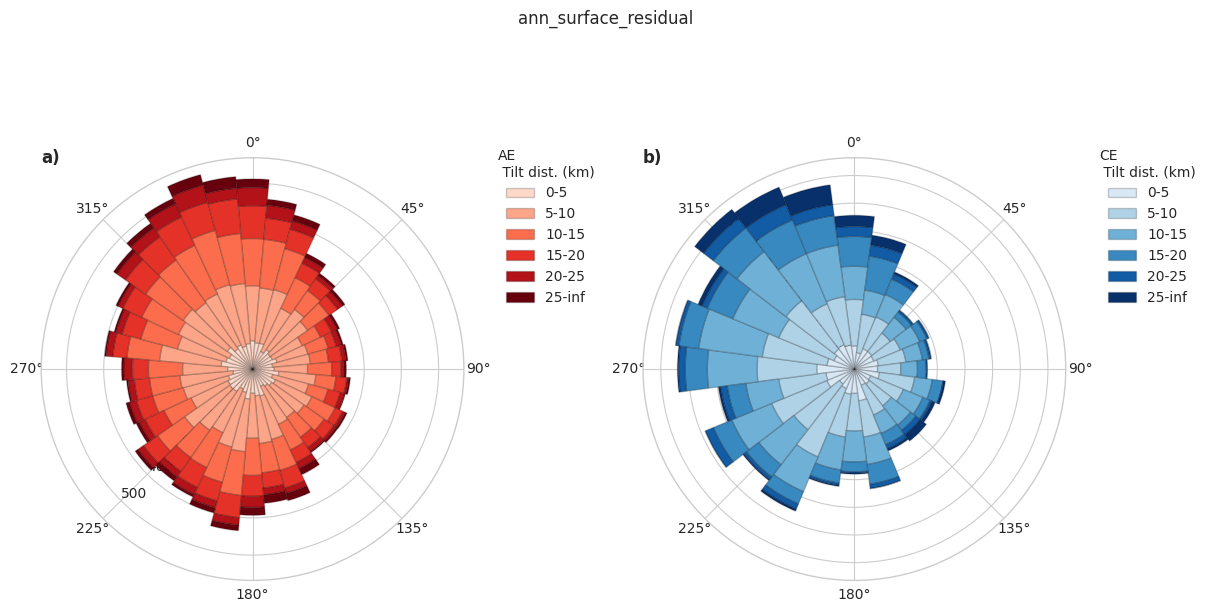

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(12, 7), subplot_kw={"projection": "polar"}, constrained_layout=True)
mag_bins = [0, 5, 10, 15, 20, 25, np.inf]
for ax, cyc, colors in zip(axs, ["AE", "CE"], [plt.cm.Reds(np.linspace(0.15, 1, len(mag_bins) - 1)), plt.cm.Blues(np.linspace(0.15, 1, len(mag_bins) - 1))]):
    subset = primary.loc[primary.Cyc == cyc].dropna(subset=["ann_surface_residual_dir", "ann_surface_residual_dis"])
    tilt.plot_windrose(ax, subset, title='', colors=colors, mag='ann_surface_residual_dis', theta='ann_surface_residual_dir', mag_bins=mag_bins)#, rlim=2300)# 
    ax.legend(title=f"{cyc}\n Tilt dist. (km)", loc="upper left", bbox_to_anchor=(1.05, 1.05), frameon=False)

    ax.text(-0.0, 1.02, 'a)' if cyc=='AE' else 'b)', transform=ax.transAxes,
                fontsize=12, fontweight='bold', va='top', ha='left')
plt.suptitle('ann_surface_residual')
plt.show()


## 3. Residual meridional propagation

Track velocities are obtained with a time-aware position derivative and then smoothed with a centred five-observation rolling median. The rotated-grid `xc`, `yc` velocities are converted to true east/north using the ROMS grid angle. Confidence intervals resample whole eddies, not individual days. Evidence for beta drift is AE residual north velocity above zero and CE residual north velocity below zero, robust across background definitions.

,Cyc,column,eddies,median,ci_low,ci_high
0,AE,track_north_ms,665,-0.011392,-0.015490,-0.008508
1,CE,track_north_ms,385,-0.014590,-0.017422,-0.009017
2,AE,ann_surface_residual_north_ms,665,0.006415,0.001092,0.011280
3,CE,ann_surface_residual_north_ms,385,0.009042,0.002280,0.019320
4,AE,ann_500_residual_north_ms,665,0.001297,-0.002516,0.004586
5,CE,ann_500_residual_north_ms,385,0.001510,-0.002822,0.006976
6,AE,clim_surface_residual_north_ms,665,-0.016765,-0.023858,-0.010271
7,CE,clim_surface_residual_north_ms,385,-0.018206,-0.032888,-0.007106
8,AE,clim_500_residual_north_ms,665,-0.006145,-0.011141,0.000226
9,CE,clim_500_residual_north_ms,385,-0.009075,-0.021624,0.000459


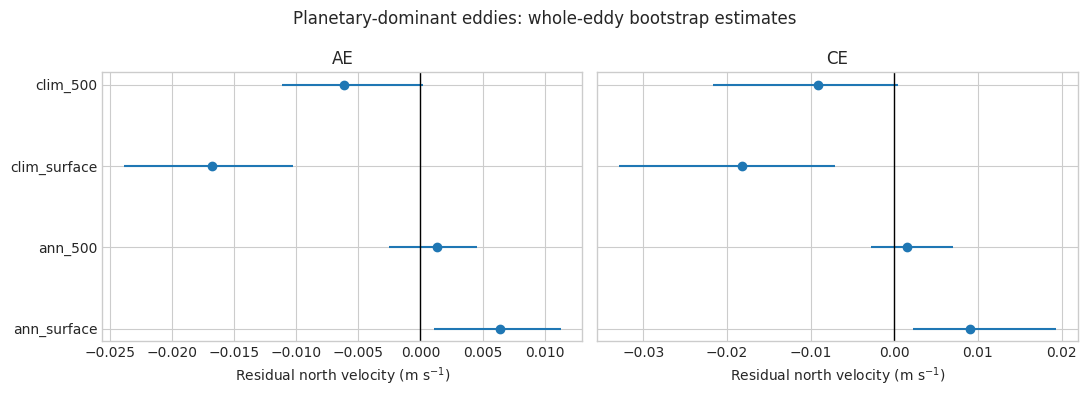

In [10]:
summary = propagation_summary(primary, n_boot=5000)
display(summary)

plot = summary[summary['column'].str.contains('residual')].copy()
plot['method'] = plot['column'].str.replace('_residual_north_ms', '', regex=False)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, (cyc, part) in zip(axes, plot.groupby('Cyc')):
    y = np.arange(len(part))
    ax.errorbar(part['median'], y, xerr=[part['median']-part['ci_low'], part['ci_high']-part['median']], fmt='o')
    ax.axvline(0, color='k', lw=1)
    ax.set(yticks=y, yticklabels=part['method'], title=cyc, xlabel='Residual north velocity (m s$^{-1}$)')
fig.suptitle('Planetary-dominant eddies: whole-eddy bootstrap estimates')
plt.tight_layout()

## 4. Vorticity-budget consistency check

For meridional residual velocity $v_r$, planetary-vorticity advection predicts $d w/dt \approx -\beta v_r$. This is a stronger mechanistic diagnostic than a simple association between vorticity and tilt. A budget residual centred near zero supports consistency, but does not alone establish causality.

,Cyc,column,eddies,median,ci_low,ci_high
0,AE,budget_residual_s2,665,-7.017008e-13,-1.234718e-12,-2.336578e-13
1,CE,budget_residual_s2,385,2.550416e-12,2.012379e-12,3.144929e-12


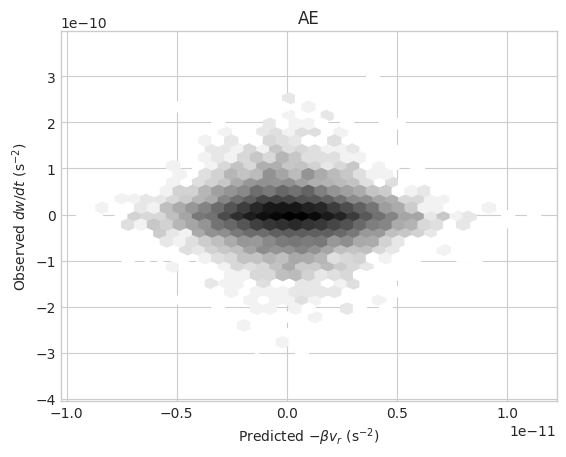

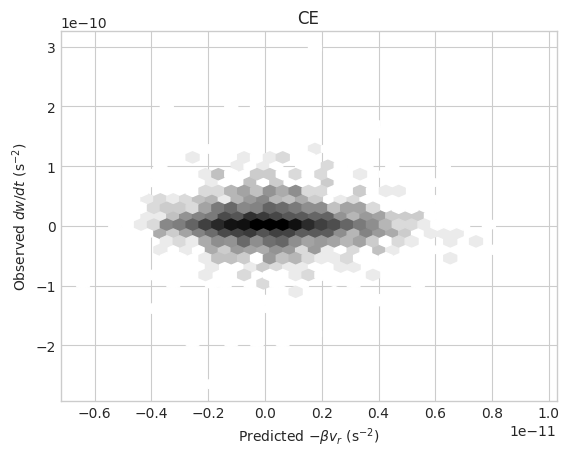

In [11]:
budget, budget_summary = vorticity_budget_summary(primary, method='ann_surface')
display(budget_summary)
for cyc, part in budget.groupby('Cyc'):
    x = part['beta_advection_s2']
    y = part['dw_dt_s2']
    use = np.isfinite(x) & np.isfinite(y)
    plt.hexbin(x[use], y[use], gridsize=35, mincnt=1, bins='log', label=cyc)
    plt.xlabel(r'Predicted $-\beta v_r$ (s$^{-2}$)')
    plt.ylabel(r'Observed $dw/dt$ (s$^{-2}$)')
    plt.title(cyc)
    plt.show()

## 5. Link residual propagation to meridional tilt

Positive aligned values mean equatorward for AEs and poleward for CEs. This section tests whether the expected residual drift and the observed tilt point in the same meridional sense. Interpret day-level correlations cautiously because repeated observations from one eddy are not independent.

In [12]:
theta = np.deg2rad(primary['TiltDir'])
primary['tilt_north_km'] = primary['TiltDis'] * np.cos(theta)
primary['aligned_tilt_km'] = primary['expected_sign'] * primary['tilt_north_km']
rows = []
for method in METHODS:
    x = primary[f'{method}_aligned_residual_north_ms']
    rows.append({'method': method, 'spearman': x.corr(primary['aligned_tilt_km'], method='spearman'),
                 'n': int((x.notna() & primary['aligned_tilt_km'].notna()).sum())})
display(pd.DataFrame(rows))

,method,spearman,n
0,ann_surface,-0.041974,14138
1,ann_500,-0.091276,14138
2,clim_surface,0.043726,14138
3,clim_500,0.006392,14138


## 6. PV-dominance sensitivity

Require progressively stronger planetary dominance. Since the cache was built for `topo_plan_ratio < 0`, thresholds here are planetary/topographic ratios of 1, 2, and 4. The polarity-specific `(w + f)` term remains in every mask.

In [13]:
sensitivity = []
for ratio in [1, 2, 4]:
    part = primary[primary['topo_plan_ratio'] < -np.log(ratio)]
    result = eddy_bootstrap_ci(part, 'ann_surface_residual_north_ms', n_boot=5000)
    result['minimum_planetary_topographic_ratio'] = ratio
    sensitivity.append(result)
display(pd.concat(sensitivity, ignore_index=True))

,Cyc,column,eddies,median,ci_low,ci_high,minimum_planetary_topographic_ratio
0,AE,ann_surface_residual_north_ms,665,0.006415,0.001092,0.011280,1
1,CE,ann_surface_residual_north_ms,385,0.009042,0.002280,0.019320,1
2,AE,ann_surface_residual_north_ms,571,0.007395,-0.000313,0.012283,2
3,CE,ann_surface_residual_north_ms,300,0.000170,-0.009450,0.015767,2
4,AE,ann_surface_residual_north_ms,345,0.013501,0.007052,0.020073,4
5,CE,ann_surface_residual_north_ms,116,-0.003063,-0.015457,0.011835,4


## Interpretation checklist

The beta-effect interpretation becomes credible if: (1) AE and CE residual meridional velocities have the predicted opposite signs; (2) signs persist for instantaneous and climatological, surface and 0–500 m backgrounds; (3) the observed vorticity tendency is consistent with `-beta * residual north velocity`; (4) the signal strengthens under stricter planetary dominance; and (5) residual propagation aligns with the polarity-specific meridional tilt. Failure of one diagnostic is informative and should not be hidden by relying only on the vorticity-versus-tilt correlation.